<a href="https://colab.research.google.com/github/ajaswal2709-arch/AI-finance-projects/blob/main/week2_stock_screener.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install yfinance
!pip install yfinance

In [2]:
# Import all libraries we need
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
reliance=yf.Ticker("RELIANCE.NS").history(period="1y")["Close"]
print(reliance)

Date
2025-06-05 00:00:00+05:30    1430.050171
2025-06-06 00:00:00+05:30    1431.140747
2025-06-09 00:00:00+05:30    1436.395386
2025-06-10 00:00:00+05:30    1426.183472
2025-06-11 00:00:00+05:30    1436.494507
                                ...     
2026-06-01 00:00:00+05:30    1313.924927
2026-06-02 00:00:00+05:30    1308.549805
2026-06-03 00:00:00+05:30    1307.156250
2026-06-04 00:00:00+05:30    1297.699951
2026-06-05 00:00:00+05:30    1291.000000
Name: Close, Length: 250, dtype: float64


In [5]:
reliance.iloc[0]

np.float64(1430.0501708984375)

In [6]:
reliance.iloc[-1]

np.float64(1291.0)

In [9]:
return_pct= (1291.0-1430.0501708984375) / 1430.0501708984375 *100
print(return_pct)

-9.723447032007163


In [13]:
tickers = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "WIPRO.NS"]

In [14]:
for t in tickers:
  data = yf.Ticker(t).history(period="1y")["Close"]
  return_pct = (data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100
  print(t, return_pct)

RELIANCE.NS -9.723447032007163
TCS.NS -32.20539715159658
HDFCBANK.NS -22.327872868083247
INFY.NS -21.776212757678117
WIPRO.NS -16.312813141958717


In [15]:
for t in tickers:
    data = yf.Ticker(t).history(period="1y")["Close"]
    return_pct = (data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100
    print(f"{t} → {round(return_pct, 2)}%")

RELIANCE.NS → -9.72%
TCS.NS → -32.21%
HDFCBANK.NS → -22.33%
INFY.NS → -21.78%
WIPRO.NS → -16.31%


In [16]:
for t in tickers:
    data = yf.Ticker(t).history(period="1y")["Close"]

    # daily returns (% change each day)
    daily_returns = data.pct_change().dropna()

    # annual return
    annual_return = (data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100

    # volatility (252 trading days in a year)
    volatility = daily_returns.std() * (252 ** 0.5) * 100

    # sharpe ratio
    sharpe = (annual_return / 100) / (volatility / 100)

    print(f"{t} | Return: {round(annual_return,2)}% | Volatility: {round(volatility,2)}% | Sharpe: {round(sharpe,2)}")

RELIANCE.NS | Return: -9.72% | Volatility: 19.94% | Sharpe: -0.49
TCS.NS | Return: -32.21% | Volatility: 24.45% | Sharpe: -1.32
HDFCBANK.NS | Return: -22.33% | Volatility: 19.24% | Sharpe: -1.16
INFY.NS | Return: -21.78% | Volatility: 26.68% | Sharpe: -0.82
WIPRO.NS | Return: -16.31% | Volatility: 23.49% | Sharpe: -0.69


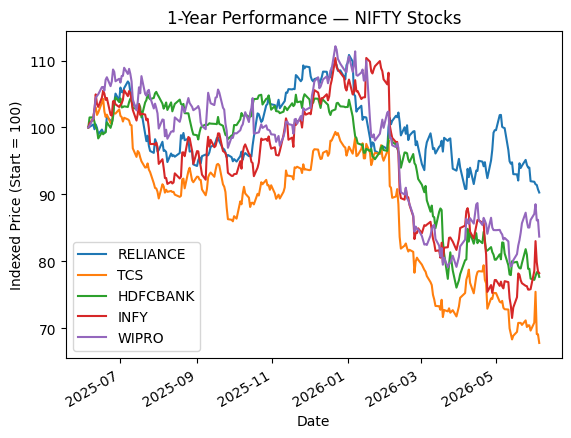

In [17]:
for t in tickers:
    data = yf.Ticker(t).history(period="1y")["Close"]
    (data / data.iloc[0] * 100).plot(label=t.replace(".NS",""))

plt.title("1-Year Performance — NIFTY Stocks")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.show()